In [2]:
!pip install -q kagglehub polars duckdb pyarrow matplotlib pandas

print("Library installed")

Library installed


In [3]:
import kagglehub

# langsung dari slug dataset
path = kagglehub.dataset_download(
    "purikhairunisa/dataset-gabungan-csv"
)

print("Dataset downloaded:")
print(path)

Using Colab cache for faster access to the 'dataset-gabungan-csv' dataset.
Dataset downloaded:
/kaggle/input/dataset-gabungan-csv


In [4]:
import os
import glob

csv_files = glob.glob(
    os.path.join(path, "**/*.csv"),
    recursive=True
)

print("CSV ditemukan:\n")

for i, file in enumerate(csv_files):
    print(f"{i+1}. {file}")

DATA_PATH = csv_files[0]

print("\nMenggunakan file:")
print(DATA_PATH)

CSV ditemukan:

1. /kaggle/input/dataset-gabungan-csv/dataset_gabungan.csv

Menggunakan file:
/kaggle/input/dataset-gabungan-csv/dataset_gabungan.csv


# Load Dataset

In [5]:
import polars as pl

df_lazy = pl.scan_csv(
    DATA_PATH,
    infer_schema_length=1000,
    ignore_errors=True
)

print("Dataset berhasil dibaca")

Dataset berhasil dibaca


In [6]:
sample_df = (
    df_lazy
    .head(10)
    .collect()
)

sample_df.to_pandas()

,article,timestamp,views
0,San_Junipero,2016072700,7
1,San_Junipero,2016072800,28
2,San_Junipero,2016072900,7
3,San_Junipero,2016073000,15
4,San_Junipero,2016073100,10
5,San_Junipero,2016080100,21
6,San_Junipero,2016080200,20
7,San_Junipero,2016080300,15
8,San_Junipero,2016080400,12
9,San_Junipero,2016080500,16


# Preprocessing

In [7]:
schema = df_lazy.collect_schema()

print("=== INFORMASI KOLOM ===\n")

for col, dtype in schema.items():
    print(f"{col} : {dtype}")

=== INFORMASI KOLOM ===

article : String
timestamp : Int64
views : Int64


In [8]:
missing = (
    df_lazy
    .null_count()
    .collect()
)

missing.to_pandas()

,article,timestamp,views
0,7674,0,0


In [9]:
# duplicate check
sample_dup = (
    df_lazy
    .limit(100000)
    .collect()
)

duplicate_count = (
    sample_dup.shape[0]
    - sample_dup.unique().shape[0]
)

print("Duplicate pada sample:")
print(duplicate_count)

Duplicate pada sample:
0


<Axes: >

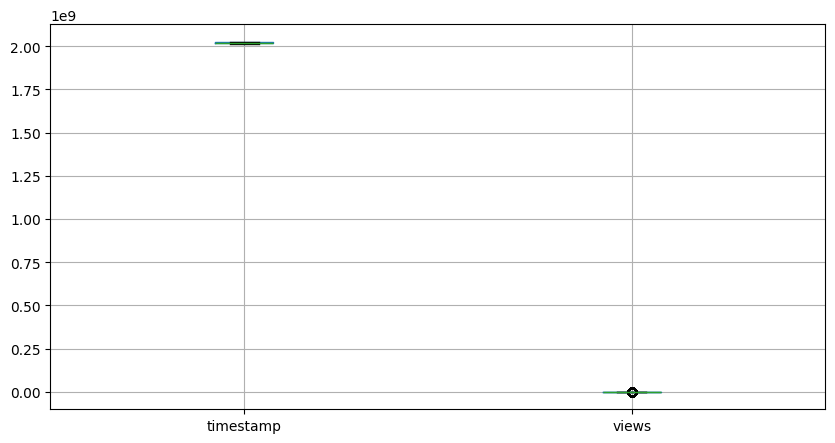

In [10]:
numeric_cols = [col for col, dtype in schema.items() if dtype == pl.Int64 or dtype == pl.Float64]

sample_df = (
    df_lazy
    .select(numeric_cols)
    .limit(100000)
    .collect()
    .to_pandas()
)

sample_df.boxplot(figsize=(10,5))

# Variability

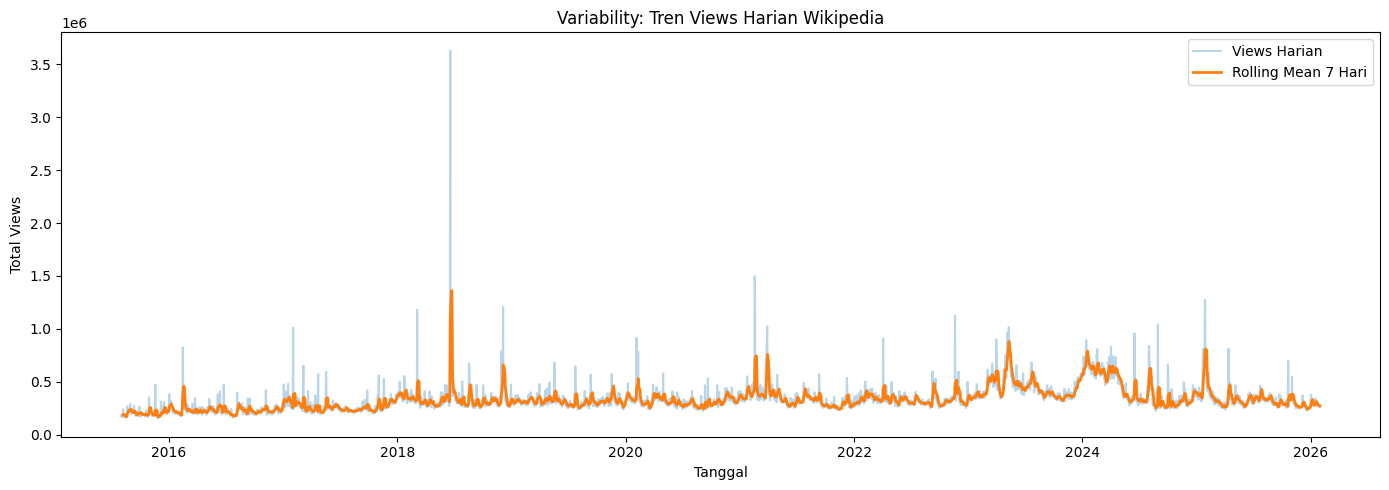

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ambil sample aman
sample_df = (
    df_lazy
    .limit(500000)
    .collect()
    .to_pandas()
)

# =====================================
# FIX TIMESTAMP WIKIPEDIA
# =====================================

sample_df['timestamp'] = pd.to_datetime(
    sample_df['timestamp'].astype(str) + '00',
    format='%Y%m%d%H%M',
    errors='coerce'
)

# hapus yang gagal parse
sample_df = sample_df.dropna(
    subset=['timestamp']
)

# =====================================
# AGREGASI HARIAN
# =====================================

daily_views = (
    sample_df
    .groupby(
        sample_df['timestamp'].dt.date
    )['views']
    .sum()
    .reset_index()
)

daily_views.columns = [
    'date',
    'views'
]

# =====================================
# ROLLING MEAN
# =====================================

daily_views['rolling_7d'] = (
    daily_views['views']
    .rolling(7)
    .mean()
)

# =====================================
# PLOT
# =====================================

plt.figure(figsize=(14,5))

plt.plot(
    daily_views['date'],
    daily_views['views'],
    alpha=0.3,
    label='Views Harian'
)

plt.plot(
    daily_views['date'],
    daily_views['rolling_7d'],
    linewidth=2,
    label='Rolling Mean 7 Hari'
)

plt.title(
    'Variability: Tren Views Harian Wikipedia'
)

plt.xlabel('Tanggal')
plt.ylabel('Total Views')

plt.legend()

plt.tight_layout()
plt.show()

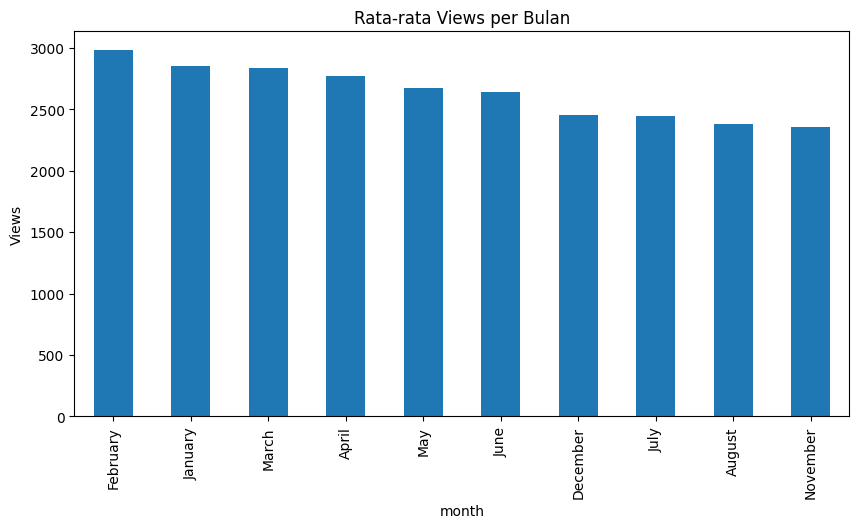

In [12]:
# bulan terpopuler

sample_df['month'] = (
    sample_df['timestamp']
    .dt.month_name()
)

monthly = (
    sample_df
    .groupby('month')['views']
    .mean()
    .sort_values(ascending=False)
)

monthly.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Rata-rata Views per Bulan'
)

plt.ylabel('Views')
plt.show()

# Volume

In [13]:
row_count = (
    df_lazy
    .select(pl.len())
    .collect()
    .item()
)

col_count = len(schema)

file_size_gb = (
    os.path.getsize(DATA_PATH)
    / (1024**3)
)

print("=== VOLUME ===")

print(f"Jumlah baris : {row_count:,}")
print(f"Jumlah kolom : {col_count}")
print(f"Ukuran file  : {file_size_gb:.2f} GB")

=== VOLUME ===
Jumlah baris : 125,027,705
Jumlah kolom : 3
Ukuran file  : 3.96 GB


Data UTS (EN)         : 64,944,259
Data EAS (EN + ID)    : 125,027,705
Penambahan data       : 60,083,446


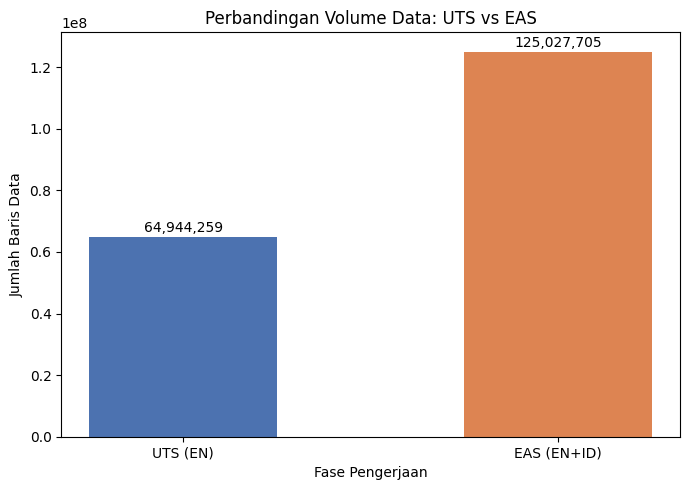

In [14]:
import matplotlib.pyplot as plt

# Perbandingan jumlah data UTS (EN saja) vs EAS (EN + ID)
data_uts = 64_944_259
data_eas = row_count
tambahan = data_eas - data_uts

print(f"Data UTS (EN)         : {data_uts:,}")
print(f"Data EAS (EN + ID)    : {data_eas:,}")
print(f"Penambahan data       : {tambahan:,}")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['UTS (EN)', 'EAS (EN+ID)'], [data_uts, data_eas], color=['#4C72B0', '#DD8452'], width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500_000,
            f"{bar.get_height():,.0f}", ha='center', va='bottom', fontsize=10)
ax.set_title('Perbandingan Volume Data: UTS vs EAS')
ax.set_ylabel('Jumlah Baris Data')
ax.set_xlabel('Fase Pengerjaan')
plt.tight_layout()
plt.show()

# Velocity

In [16]:
# Interval rata-rata antar data
# Convert 'timestamp' from Int64 (YYYYMMDDHH) to Datetime for proper interval calculation
df_with_datetime = df_lazy.with_columns(
    (pl.col("timestamp").cast(pl.Utf8) + pl.lit("00")) # Append '00' for minutes using '+' operator
    .str.strptime(pl.Datetime, format="%Y%m%d%H%M") # Use format with minutes
    .alias("actual_timestamp")
)

# Calculate the difference between consecutive datetime values
# First, sort by the timestamp to ensure meaningful intervals
interval_series = df_with_datetime.sort("actual_timestamp").select(
    pl.col("actual_timestamp").diff()
).collect().to_series()

# Calculate the mean of the interval (Polars Series.mean() ignores nulls by default)
mean_interval = interval_series.mean()

# Get unique hours from the datetime column
unique_hours = df_with_datetime.select(
    pl.col("actual_timestamp").dt.hour()
).unique().collect().to_series().to_list()

print("Rata-rata interval:", mean_interval)
print("Jam unik:", unique_hours)

Rata-rata interval: 0:00:02.650855
Jam unik: [0]


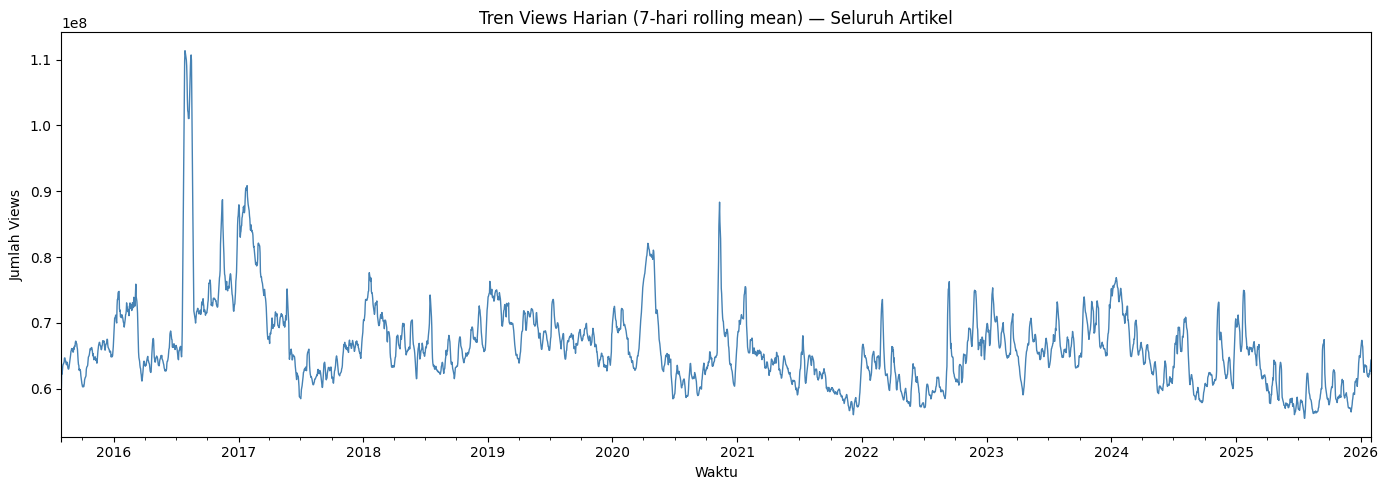

In [17]:
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd # Import pandas for plotting and rolling functions

# Group by 'actual_timestamp' and sum 'views' using Polars
df_harian_polars = df_with_datetime.group_by('actual_timestamp').agg(
    pl.sum('views').alias('total_views')
).sort('actual_timestamp') # Sort by timestamp for correct rolling calculation

# Collect the Polars DataFrame and convert to Pandas for plotting
df_harian_pandas = df_harian_polars.collect().to_pandas().set_index('actual_timestamp')

fig, ax = plt.subplots(figsize=(14, 5))
# Apply a 7-day rolling mean and plot
df_harian_pandas['total_views'].rolling(window='7D').mean().plot(ax=ax, color='steelblue', linewidth=1)
ax.set_title('Tren Views Harian (7-hari rolling mean) — Seluruh Artikel')
ax.set_xlabel('Waktu')
ax.set_ylabel('Jumlah Views')
plt.tight_layout()
plt.show()

# Variety

In [18]:
import pandas as pd

variety_df = pd.DataFrame({
    "Kolom": list(schema.keys()),
    "Tipe Data": [str(x) for x in schema.values()]
})

variety_df

,Kolom,Tipe Data
0,article,String
1,timestamp,Int64
2,views,Int64


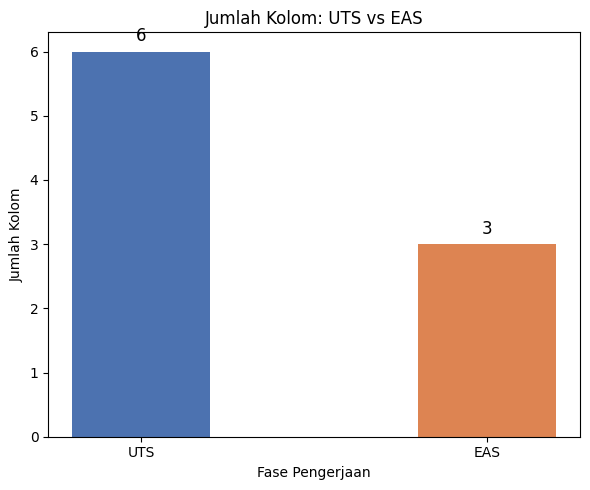

In [19]:
import matplotlib.pyplot as plt

# Perbandingan kolom UTS vs EAS
kolom_uts = 6
# Use the already calculated 'col_count' from the kernel state
kolom_eas = col_count

# Since only one plot can be generated, create a single subplot
fig, ax = plt.subplots(1, 1, figsize=(6, 5)) # Adjusted for a single plot

# Bar chart kolom
ax.bar(['UTS', 'EAS'], [kolom_uts, kolom_eas], color=['#4C72B0', '#DD8452'], width=0.4)
for i, v in enumerate([kolom_uts, kolom_eas]):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=12)
ax.set_title('Jumlah Kolom: UTS vs EAS')
ax.set_ylabel('Jumlah Kolom')
ax.set_xlabel('Fase Pengerjaan') # Adding x-label for clarity

# Pie chart distribusi bahasa - This section is commented out because
# the 'bahasa' column does not exist in the current dataset ('df_lazy').
# If you have another categorical column you'd like to visualize,
# please let me know!
# bahasa_count = df['bahasa'].value_counts()
# axes[1].pie(bahasa_count, labels=bahasa_count.index, autopct='%1.1f%%',
#             colors=['#4C72B0', '#DD8452'], startangle=90)
# axes[1].set_title('Distribusi Data per Bahasa (EN vs ID)')

plt.tight_layout()
plt.show()

# Veracity

=== VERACITY ===

Data awal              : 125,027,705
Duplikat (sample)      : 0
Missing value (sample) : 0
Data valid sample      : 100,000


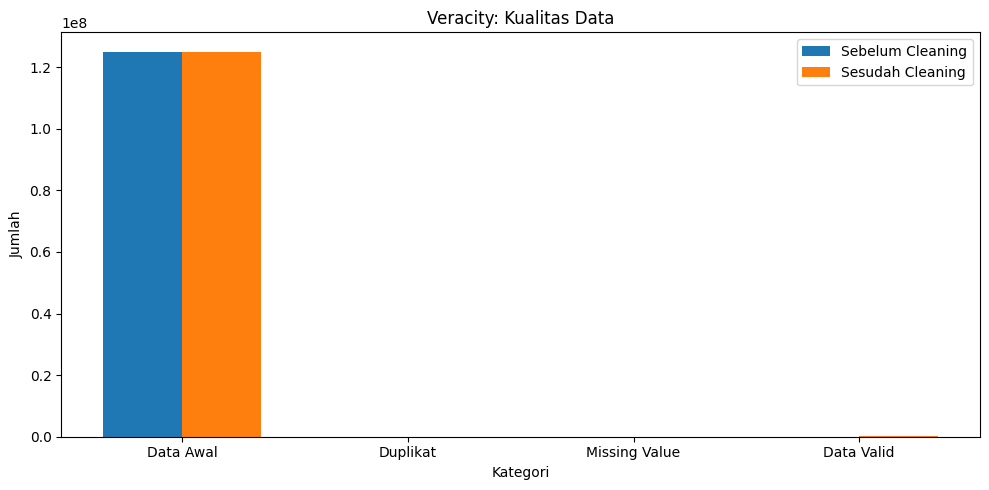

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================
# SAMPLE DATA (AMAN RAM)
# ==================================

sample_df = (
    df_lazy
    .limit(100000)  # cukup 100 ribu
    .collect()
    .to_pandas()
)

# ==================================
# HITUNG VERACITY
# ==================================

data_awal = row_count

duplikat_sbl = sample_df.duplicated().sum()

missing_sbl = (
    sample_df
    .isnull()
    .sum()
    .sum()
)

data_sesudah = (
    sample_df.shape[0]
    - duplikat_sbl
)

# ==================================
# OUTPUT TEXT
# ==================================

print("=== VERACITY ===\n")

print("Data awal              :", f"{data_awal:,}")
print("Duplikat (sample)      :", f"{duplikat_sbl:,}")
print("Missing value (sample) :", f"{missing_sbl:,}")
print("Data valid sample      :", f"{data_sesudah:,}")

# ==================================
# VISUALISASI
# ==================================

kategori = [
    "Data Awal",
    "Duplikat",
    "Missing Value",
    "Data Valid"
]

sebelum = [
    data_awal,
    duplikat_sbl,
    missing_sbl,
    0
]

sesudah = [
    data_awal,
    0,
    0,
    data_sesudah
]

x = np.arange(len(kategori))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))

b1 = ax.bar(
    x - width/2,
    sebelum,
    width,
    label="Sebelum Cleaning"
)

b2 = ax.bar(
    x + width/2,
    sesudah,
    width,
    label="Sesudah Cleaning"
)

ax.set_title(
    "Veracity: Kualitas Data"
)

ax.set_ylabel("Jumlah")
ax.set_xlabel("Kategori")

ax.set_xticks(x)
ax.set_xticklabels(kategori)

ax.legend()

plt.tight_layout()
plt.show()

# Value

Kolom numerik:
['timestamp', 'views']

Kolom kategorikal:
['article']

Top kategori:
article
Washington_Capitals                               3837
2016_NBA_draft                                    3837
Jury_nullification                                3837
List_of_highest_paid_American_television_stars    3837
New_Girl                                          3837
Beverley_Callard                                  3837
Homi_J._Bhabha                                    3837
New_York_(state)                                  3837
Josh_Duggar                                       3837
Mr._T                                             3837
Name: count, dtype: int64


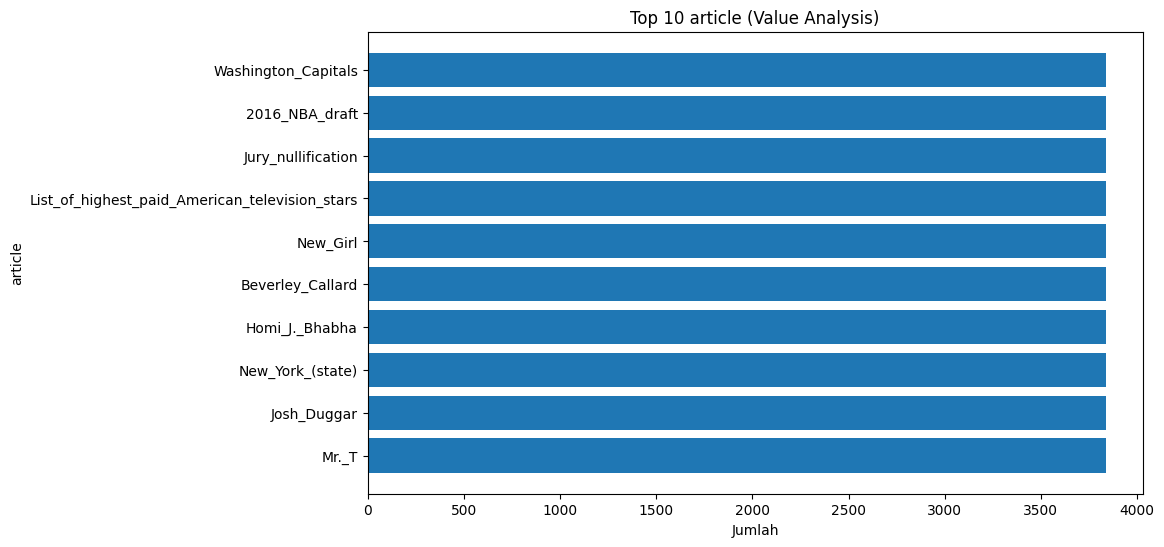

In [21]:
import matplotlib.pyplot as plt

# ==================================
# SAMPLE DATA (AMAN RAM)
# ==================================

sample_df = (
    df_lazy
    .limit(100000)
    .collect()
    .to_pandas()
)

# ==================================
# DETEKSI KOLOM
# ==================================

numeric_cols = sample_df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = sample_df.select_dtypes(
    include=['object']
).columns.tolist()

print("Kolom numerik:")
print(numeric_cols)

print("\nKolom kategorikal:")
print(categorical_cols)

# ==================================
# VALUE ANALYSIS
# ==================================

if len(categorical_cols) > 0:

    category_col = categorical_cols[0]

    top_value = (
        sample_df[category_col]
        .value_counts()
        .head(10)
    )

    print("\nTop kategori:")
    print(top_value)

    # =============================
    # VISUALISASI
    # =============================

    plt.figure(figsize=(10,6))

    plt.barh(
        top_value.index.astype(str),
        top_value.values
    )

    plt.xlabel("Jumlah")
    plt.ylabel(category_col)

    plt.title(
        f"Top 10 {category_col} (Value Analysis)"
    )

    plt.gca().invert_yaxis()

    plt.show()

else:
    print("Tidak ditemukan kolom kategorikal")

# Validity

=== VALIDITY ===

Rentang waktu: 2015080100 hingga 2026013100

views minimum : 0
views maksimum: 901393
views rata-rata: 2400.75
views median: 975.0

Jumlah unik article: 35


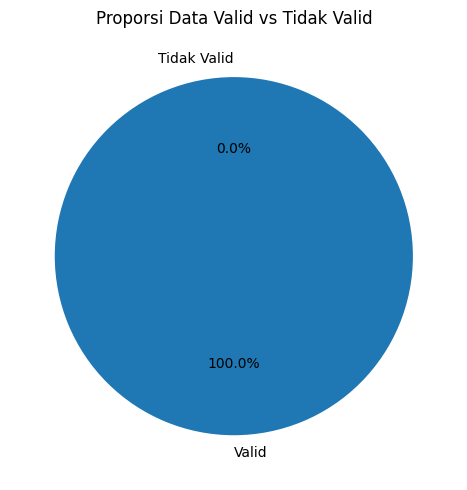

In [24]:
import matplotlib.pyplot as plt

# ==================================
# DEFINE COLUMN NAMES
# ==================================
date_col = 'timestamp'
value_col = 'views'

# category_col is already defined in a previous cell as 'article'
# If it's not defined, it should be defined here too. Example:
# category_col = 'article'

# ==================================
# VALIDITY STATS
# ==================================

print("=== VALIDITY ===\n")

if date_col:
    print(
        "Rentang waktu:",
        sample_df[date_col].min(),
        "hingga",
        sample_df[date_col].max()
    )

print(
    f"\n{value_col} minimum :",
    sample_df[value_col].min()
)

print(
    f"{value_col} maksimum:",
    sample_df[value_col].max()
)

print(
    f"{value_col} rata-rata:",
    round(sample_df[value_col].mean(), 2)
)

print(
    f"{value_col} median:",
    sample_df[value_col].median()
)

if category_col:
    print(
        f"\nJumlah unik {category_col}:",
        sample_df[category_col].nunique()
    )

# ==================================
# VALID VS TIDAK VALID
# ==================================

total_awal = row_count

missing = (
    sample_df
    .isnull()
    .sum()
    .sum()
)

duplicate = (
    sample_df
    .duplicated()
    .sum()
)

tidak_valid = (
    missing + duplicate
)

valid = (
    total_awal - tidak_valid
)

# ==================================
# VISUALISASI
# ==================================

fig, ax = plt.subplots(
    figsize=(7,5)
)

ax.pie(
    [valid, tidak_valid],
    labels=[
        "Valid",
        "Tidak Valid"
    ],
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    "Proporsi Data Valid vs Tidak Valid"
)

plt.tight_layout()
plt.show()

# Visualization

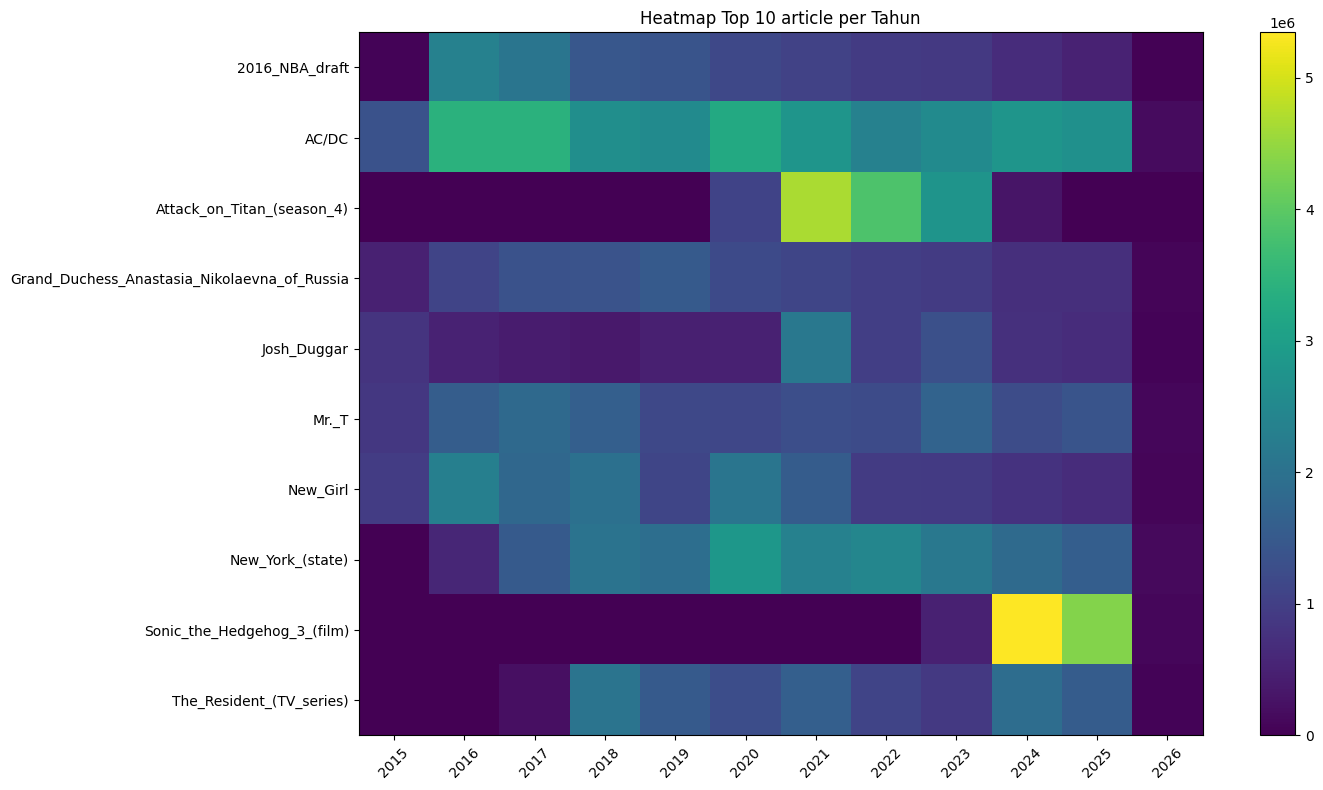

In [26]:
# ==================================
# TOP KATEGORI
# ==================================

TOP_N = 10

# Ensure 'timestamp' is a datetime object in sample_df
sample_df['timestamp'] = pd.to_datetime(
    sample_df['timestamp'].astype(str) + '00',
    format='%Y%m%d%H%M',
    errors='coerce'
)
sample_df.dropna(subset=['timestamp'], inplace=True)

top_categories = (
    sample_df
    .groupby(category_col)[value_col]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

# ==================================
# YEARLY DATA
# ==================================

# Ensure 'year' column exists in sample_df before grouping
sample_df['year'] = sample_df[date_col].dt.year

yearly_data = (
    sample_df
    .groupby(["year", category_col])[value_col]
    .sum()
    .reset_index()
)

heat_data = yearly_data[
    yearly_data[category_col]
    .isin(top_categories)
]

pivot = heat_data.pivot(
    index=category_col,
    columns="year",
    values=value_col
).fillna(0)

# ==================================
# VISUALISASI HEATMAP
# ==================================

fig, ax = plt.subplots(
    figsize=(14,8)
)

im = ax.imshow(pivot)

ax.set_xticks(
    range(len(pivot.columns))
)

ax.set_yticks(
    range(len(pivot.index))
)

ax.set_xticklabels(
    pivot.columns
)

ax.set_yticklabels(
    pivot.index.astype(str)
)

plt.colorbar(im)

ax.set_title(
    f"Heatmap Top {TOP_N} "
    f"{category_col} per Tahun"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Analisis Lanjutan

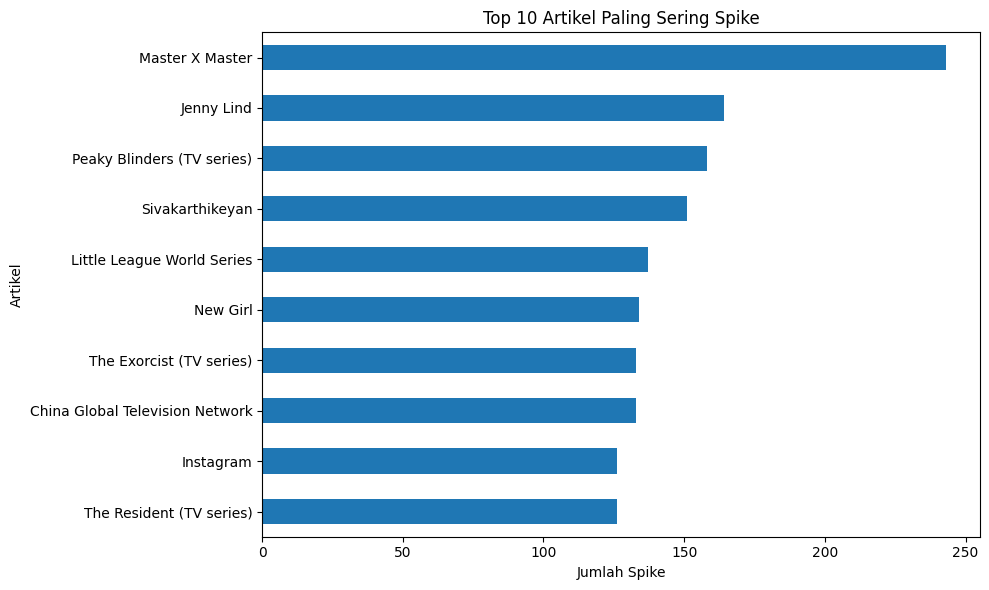

In [27]:
# ==================================
# SAMPLE DATA (AMAN RAM)
# ==================================

sample_df = (
    df_lazy
    .limit(500000)
    .collect()
    .to_pandas()
)

# ==================================
# FIX DATETIME
# ==================================

sample_df['timestamp'] = pd.to_datetime(
    sample_df['timestamp'].astype(str) + '00',
    format='%Y%m%d%H%M',
    errors='coerce'
)

# ==================================
# CLEAN NAMA ARTIKEL
# ==================================

sample_df['article_clean'] = (
    sample_df['article']
    .astype(str)
    .str.replace(
        '_',
        ' ',
        regex=False
    )
)

# ==================================
# AGREGASI HARIAN
# ==================================

daily_article = (
    sample_df
    .groupby([
        sample_df['timestamp'].dt.date,
        'article_clean'
    ])['views']
    .sum()
    .reset_index()
)

daily_article.columns = [
    'date',
    'article_clean',
    'views'
]

# ==================================
# DETEKSI SPIKE
# mean + 2 std
# ==================================

article_stats = (
    daily_article
    .groupby('article_clean')['views']
    .agg(['mean', 'std'])
    .reset_index()
)

daily_article = daily_article.merge(
    article_stats,
    on='article_clean'
)

daily_article['threshold'] = (
    daily_article['mean']
    + 2 * daily_article['std']
)

daily_article['is_spike'] = (
    daily_article['views']
    > daily_article['threshold']
)

# ==================================
# TOP SPIKE
# ==================================

spike_count = (
    daily_article[
        daily_article['is_spike']
    ]
    .groupby('article_clean')
    ['is_spike']
    .count()
    .sort_values(
        ascending=False
    )
    .head(10)
)

# ==================================
# VISUALISASI
# ==================================

fig, ax = plt.subplots(
    figsize=(10,6)
)

spike_count.plot(
    kind='barh',
    ax=ax
)

ax.set_title(
    'Top 10 Artikel Paling Sering Spike'
)

ax.set_xlabel(
    'Jumlah Spike'
)

ax.set_ylabel(
    'Artikel'
)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

article_clean
XXXTentacion                  116754083
Instagram                     104572616
Priyanka Chopra                60498092
Peaky Blinders (TV series)     56588172
Stevie Nicks                   31545745
AC/DC                          29905738
Sherlock (TV series)           25706031
George III                     24395076
Madonna (entertainer)          24228134
Lion                           23441014
Name: views, dtype: int64


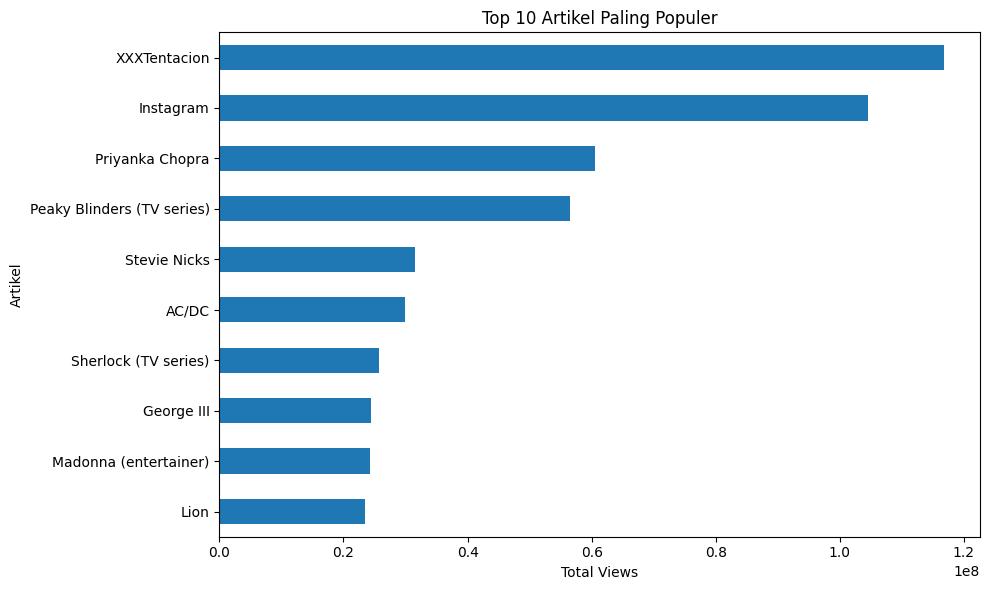

In [28]:
# ==================================
# TOP ARTICLE POPULARITY
# ==================================

top_articles = (
    sample_df
    .groupby('article_clean')['views']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print(top_articles)

# ==================================
# VISUALISASI
# ==================================

fig, ax = plt.subplots(
    figsize=(10,6)
)

top_articles.sort_values().plot(
    kind='barh',
    ax=ax
)

ax.set_title(
    'Top 10 Artikel Paling Populer'
)

ax.set_xlabel(
    'Total Views'
)

ax.set_ylabel(
    'Artikel'
)

plt.tight_layout()
plt.show()

Artikel tertentu mengalami pertumbuhan views yang sangat tinggi, mengindikasikan adanya momentum berita atau tren tertentu.